<a href="https://colab.research.google.com/github/cavalcantiju/proj1.3_DS_vendacasas/blob/main/proj1_DS_vendacasas.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [3]:
import pandas as pd

dados = pd.read_csv("/content/Preços_de_casas.csv")
dados.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1438 entries, 0 to 1437
Data columns (total 8 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   Id                              1438 non-null   int64  
 1   area_primeiro_andar             1438 non-null   float64
 2   existe_segundo_andar            1438 non-null   int64  
 3   area_segundo_andar              1438 non-null   float64
 4   quantidade_banheiros            1438 non-null   int64  
 5   capacidade_carros_garagem       1438 non-null   int64  
 6   qualidade_da_cozinha_Excelente  1438 non-null   int64  
 7   preco_de_venda                  1438 non-null   float64
dtypes: float64(3), int64(5)
memory usage: 90.0 KB


In [4]:
dados = dados.drop(columns = "Id")

In [5]:
dados.head()

,area_primeiro_andar,existe_segundo_andar,area_segundo_andar,quantidade_banheiros,capacidade_carros_garagem,qualidade_da_cozinha_Excelente,preco_de_venda
0,79.5224,1,79.3366,2,548,0,1027905.0
1,117.2398,0,0.0000,2,460,0,894795.0
2,85.4680,1,80.4514,2,608,0,1101855.0
3,89.2769,1,70.2324,1,642,0,690200.0
4,106.3705,1,97.8237,2,836,0,1232500.0


In [6]:
#quais fatores tão relacionados ao preço da casa? o coeficiente de correlação
#mede a relaçao entre as var. 1: corr positiva perfeita: uma var aumenta a
#outra tb. 0 = sem relacao. -1: corr negatv pfta: uma var aumenta a outra diminui

corr = dados.corr()

In [7]:
corr["preco_de_venda"]

,preco_de_venda
area_primeiro_andar,0.616557
existe_segundo_andar,0.138541
area_segundo_andar,0.305311
quantidade_banheiros,0.563132
capacidade_carros_garagem,0.640214
qualidade_da_cozinha_Excelente,0.496223
preco_de_venda,1.000000


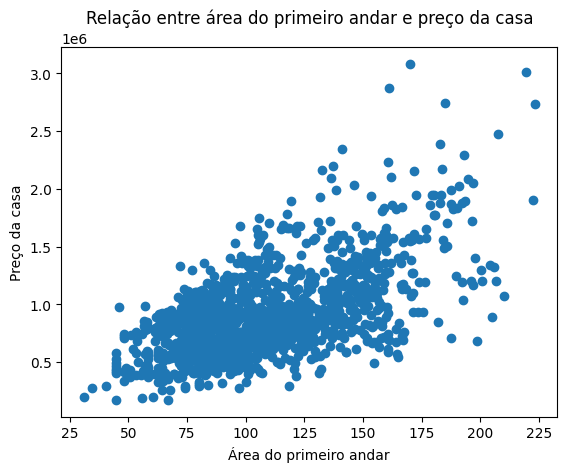

In [8]:
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

plt.scatter(dados["area_primeiro_andar"], dados["preco_de_venda"])
plt.title("Relação entre área do primeiro andar e preço da casa")
plt.xlabel("Área do primeiro andar")
plt.ylabel("Preço da casa")
plt.show()

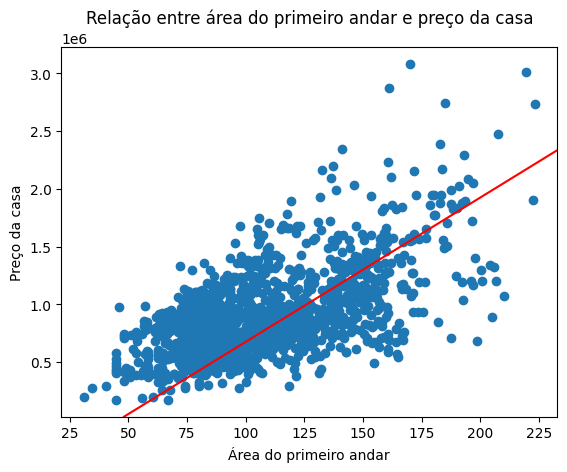

In [9]:
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

plt.scatter(dados["area_primeiro_andar"], dados["preco_de_venda"])
plt.axline(xy1 = (66, 250000), xy2 = (190, 1800000), color = 'red')
plt.title("Relação entre área do primeiro andar e preço da casa")
plt.xlabel("Área do primeiro andar")
plt.ylabel("Preço da casa")
plt.show()

In [10]:
#QUAL A MELHOR RETA?
px.scatter(dados, x = "area_primeiro_andar", y = "preco_de_venda", trendline_color_override= "red", trendline = 'ols')

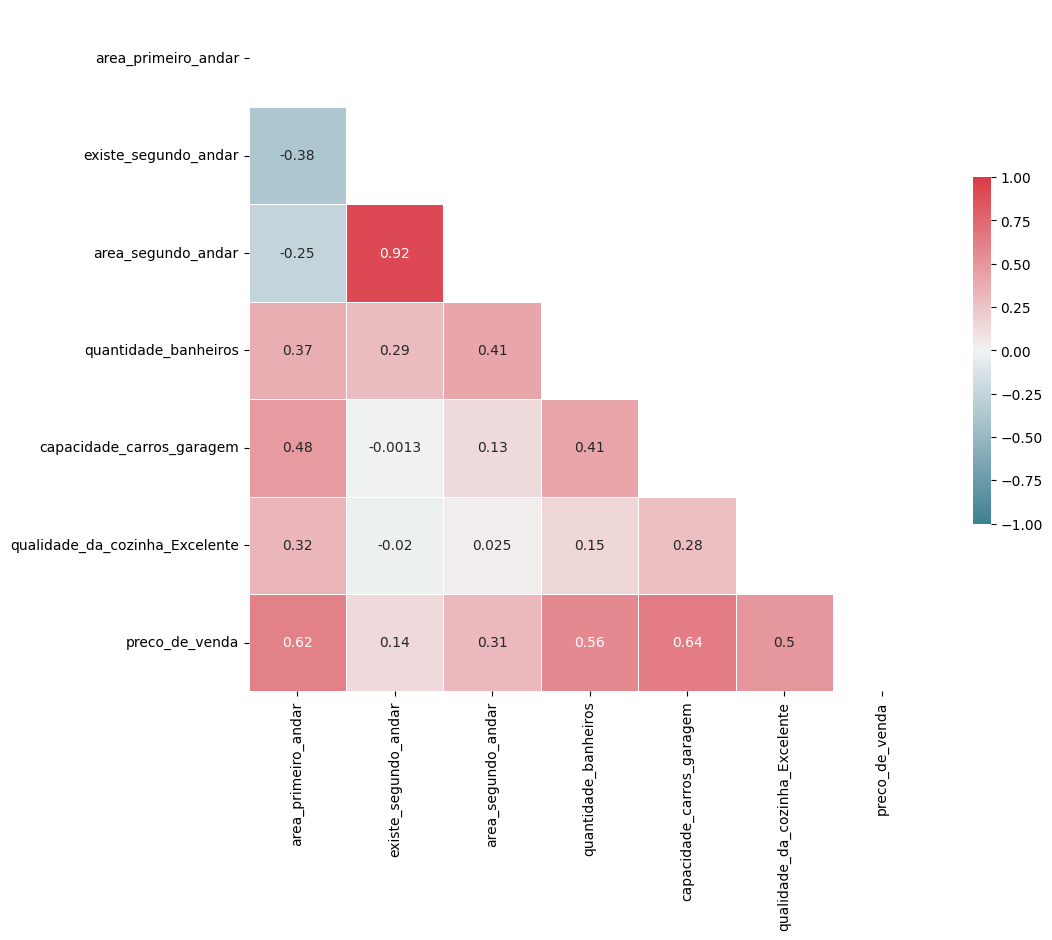

In [11]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Gerar uma máscara para o triângulo superior
mascara = np.zeros_like(corr, dtype=bool)
mascara[np.triu_indices_from(mascara)] = True

# Configurar a figura do matplotlib
f, ax = plt.subplots(figsize=(11, 9))

# Gerar o mapa de calor (heatmap)
cmap = sns.diverging_palette(220, 10, as_cmap=True)

sns.heatmap(corr, mask=mascara, cmap=cmap, vmax=1, vmin=-1, center=0,
            square=True, linewidths=.5, annot=True, cbar_kws={"shrink": .5})

# Exibir o mapa de calor (heatmap)
plt.show()

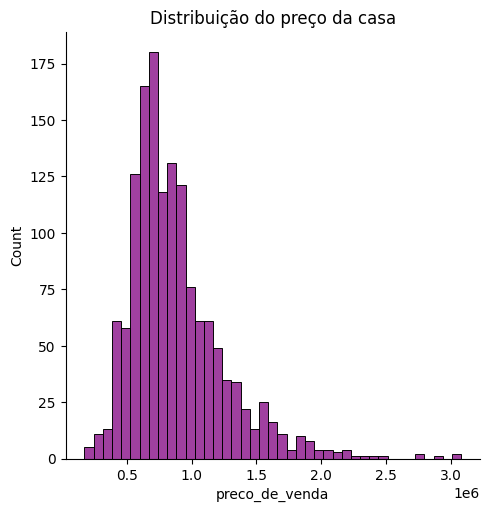

In [12]:

sns.displot(dados["preco_de_venda"], color = 'purple')
plt.title("Distribuição do preço da casa")
plt.show()

In [13]:
from sklearn.model_selection import train_test_split
y = dados['preco_de_venda']
x = dados.drop(columns = 'preco_de_venda')
x.head()

,area_primeiro_andar,existe_segundo_andar,area_segundo_andar,quantidade_banheiros,capacidade_carros_garagem,qualidade_da_cozinha_Excelente
0,79.5224,1,79.3366,2,548,0
1,117.2398,0,0.0000,2,460,0
2,85.4680,1,80.4514,2,608,0
3,89.2769,1,70.2324,1,642,0
4,106.3705,1,97.8237,2,836,0


In [14]:
X_train, X_test, y_train, y_test = train_test_split(x, y, test_size = 0.3, random_state= 230)
df_train = pd.DataFrame(data = X_train)
df_train['preco_de_venda'] = y_train

df_train.head()

,area_primeiro_andar,existe_segundo_andar,area_segundo_andar,quantidade_banheiros,capacidade_carros_garagem,qualidade_da_cozinha_Excelente,preco_de_venda
1303,65.7732,0,0.0000,1,0,0,406725.0
326,55.3684,1,55.3684,1,189,0,384540.0
386,74.6916,1,107.4853,2,560,0,1059950.0
615,103.6764,0,0.0000,1,440,0,788800.0
236,94.2006,1,67.8170,2,457,0,958885.0


In [15]:
from statsmodels.formula.api import ols
modelo_0 = ols('preco_de_venda ~ area_primeiro_andar', data = df_train).fit()
modelo_0.params

,0
Intercept,152909.288334
area_primeiro_andar,6793.641641


## Interpretação do Modelo de Regressão

O modelo estimado foi:

preco_de_venda = 152909.29 + 6793.64 * area_primeiro_andar

### Intercepto (152.909,29)

Representa o preço estimado quando a área do primeiro andar é igual a zero.  
Embora não tenha interpretação prática real, ele posiciona a reta de regressão.

### Coeficiente da área (6.793,64)

Indica que, para cada aumento de 1 unidade em `area_primeiro_andar`,  
o preço do imóvel aumenta, em média, R$ 6.793,64.

Ou seja, quanto maior a área do primeiro andar, maior tende a ser o preço do imóvel.

In [16]:
print(modelo_0.summary())

                            OLS Regression Results                            
Dep. Variable:         preco_de_venda   R-squared:                       0.377
Model:                            OLS   Adj. R-squared:                  0.377
Method:                 Least Squares   F-statistic:                     608.3
Date:                Mon, 16 Mar 2026   Prob (F-statistic):          2.22e-105
Time:                        17:07:53   Log-Likelihood:                -14082.
No. Observations:                1006   AIC:                         2.817e+04
Df Residuals:                    1004   BIC:                         2.818e+04
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                          coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------------
Intercept            1.529e+05   3

🔹 1️⃣ R² = 0.377 (COEFICIENTE DE DETERMINAÇÃO)

Significa que:

37,7% da variação do preço de venda é explicada pela variável area_primeiro_andar. uNS 62% vai ser explicado por outros fatores como banheiro, outras coisas q nao seja area do primeiro andar

Modelo de Regressão Linear

A forma geral da regressão linear simples é:

$$
Y = \beta_0 + \beta_1 X + e
$$

Onde:

- **Y** → Variável resposta (dependente).
- **β₀** → Intercepto (valor de Y quando X = 0).
- **β₁** → Coeficiente angular (impacto de X sobre Y).
- **X** → Variável explicativa (independente).
- **e** → Erro residual.


Equação Estimada

$$
\widehat{preco\_de\_venda} = 152900 + 6793.64 \cdot area\_primeiro\_andar
$$

- 152900 → Intercepto  
- 6793.64 → Aumento médio no preço para cada unidade adicional de área

In [17]:
modelo_0.resid

,0
1303,-193023.838744
326,-144522.356193
386,399612.747641
615,-68449.596607
236,166010.592859
...,...
777,465872.680999
271,-497642.319788
723,461150.204718
560,-540482.733402


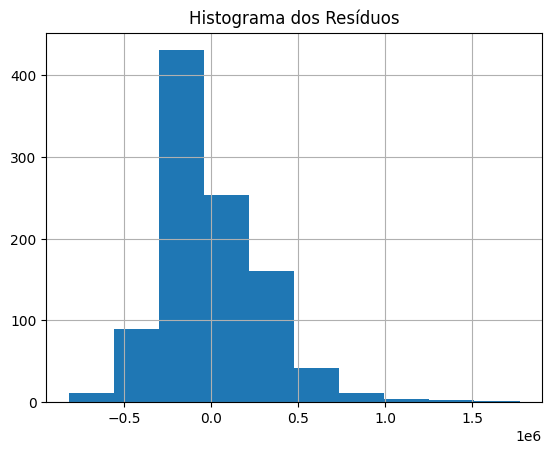

In [18]:
#RESIDUOS
modelo_0.resid.hist()
plt.title("Histograma dos Resíduos")
plt.show()

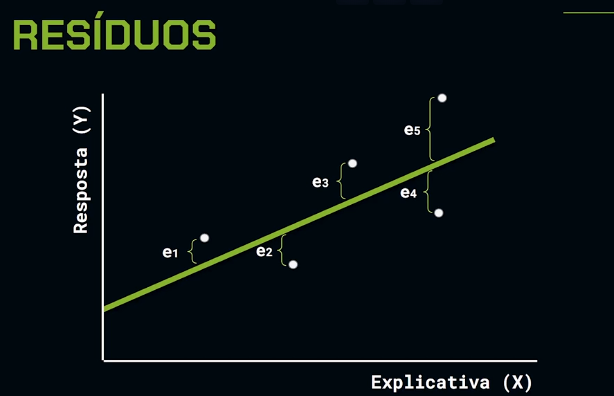

o resíduo é a distância vertical entre o ponto real (o que aconteceu de fato) e a linha de regressão (o que o seu modelo previu).Ponto acima da linha: O valor real foi maior que a previsão (resíduo positivo).Ponto abaixo da linha: O valor real foi menor que a previsão (resíduo negativo).A conta é simples: $Resíduo = Valor Real - Valor Previsto$

In [19]:
# AGORA vou usar os dados de teste pra ver se o modelo conseguiu aprender bem
# Eu tinha usado r² com os dados de treino agr to usando c o de teste p ver se ele acha um numero ~~
# definindo o y previsto
y_predict = modelo_0.predict(X_test)

#importando r2_score
from sklearn.metrics import r2_score
#printando o r²
print("R²: ", r2_score(y_test, y_predict))

R²:  0.38530928723202407


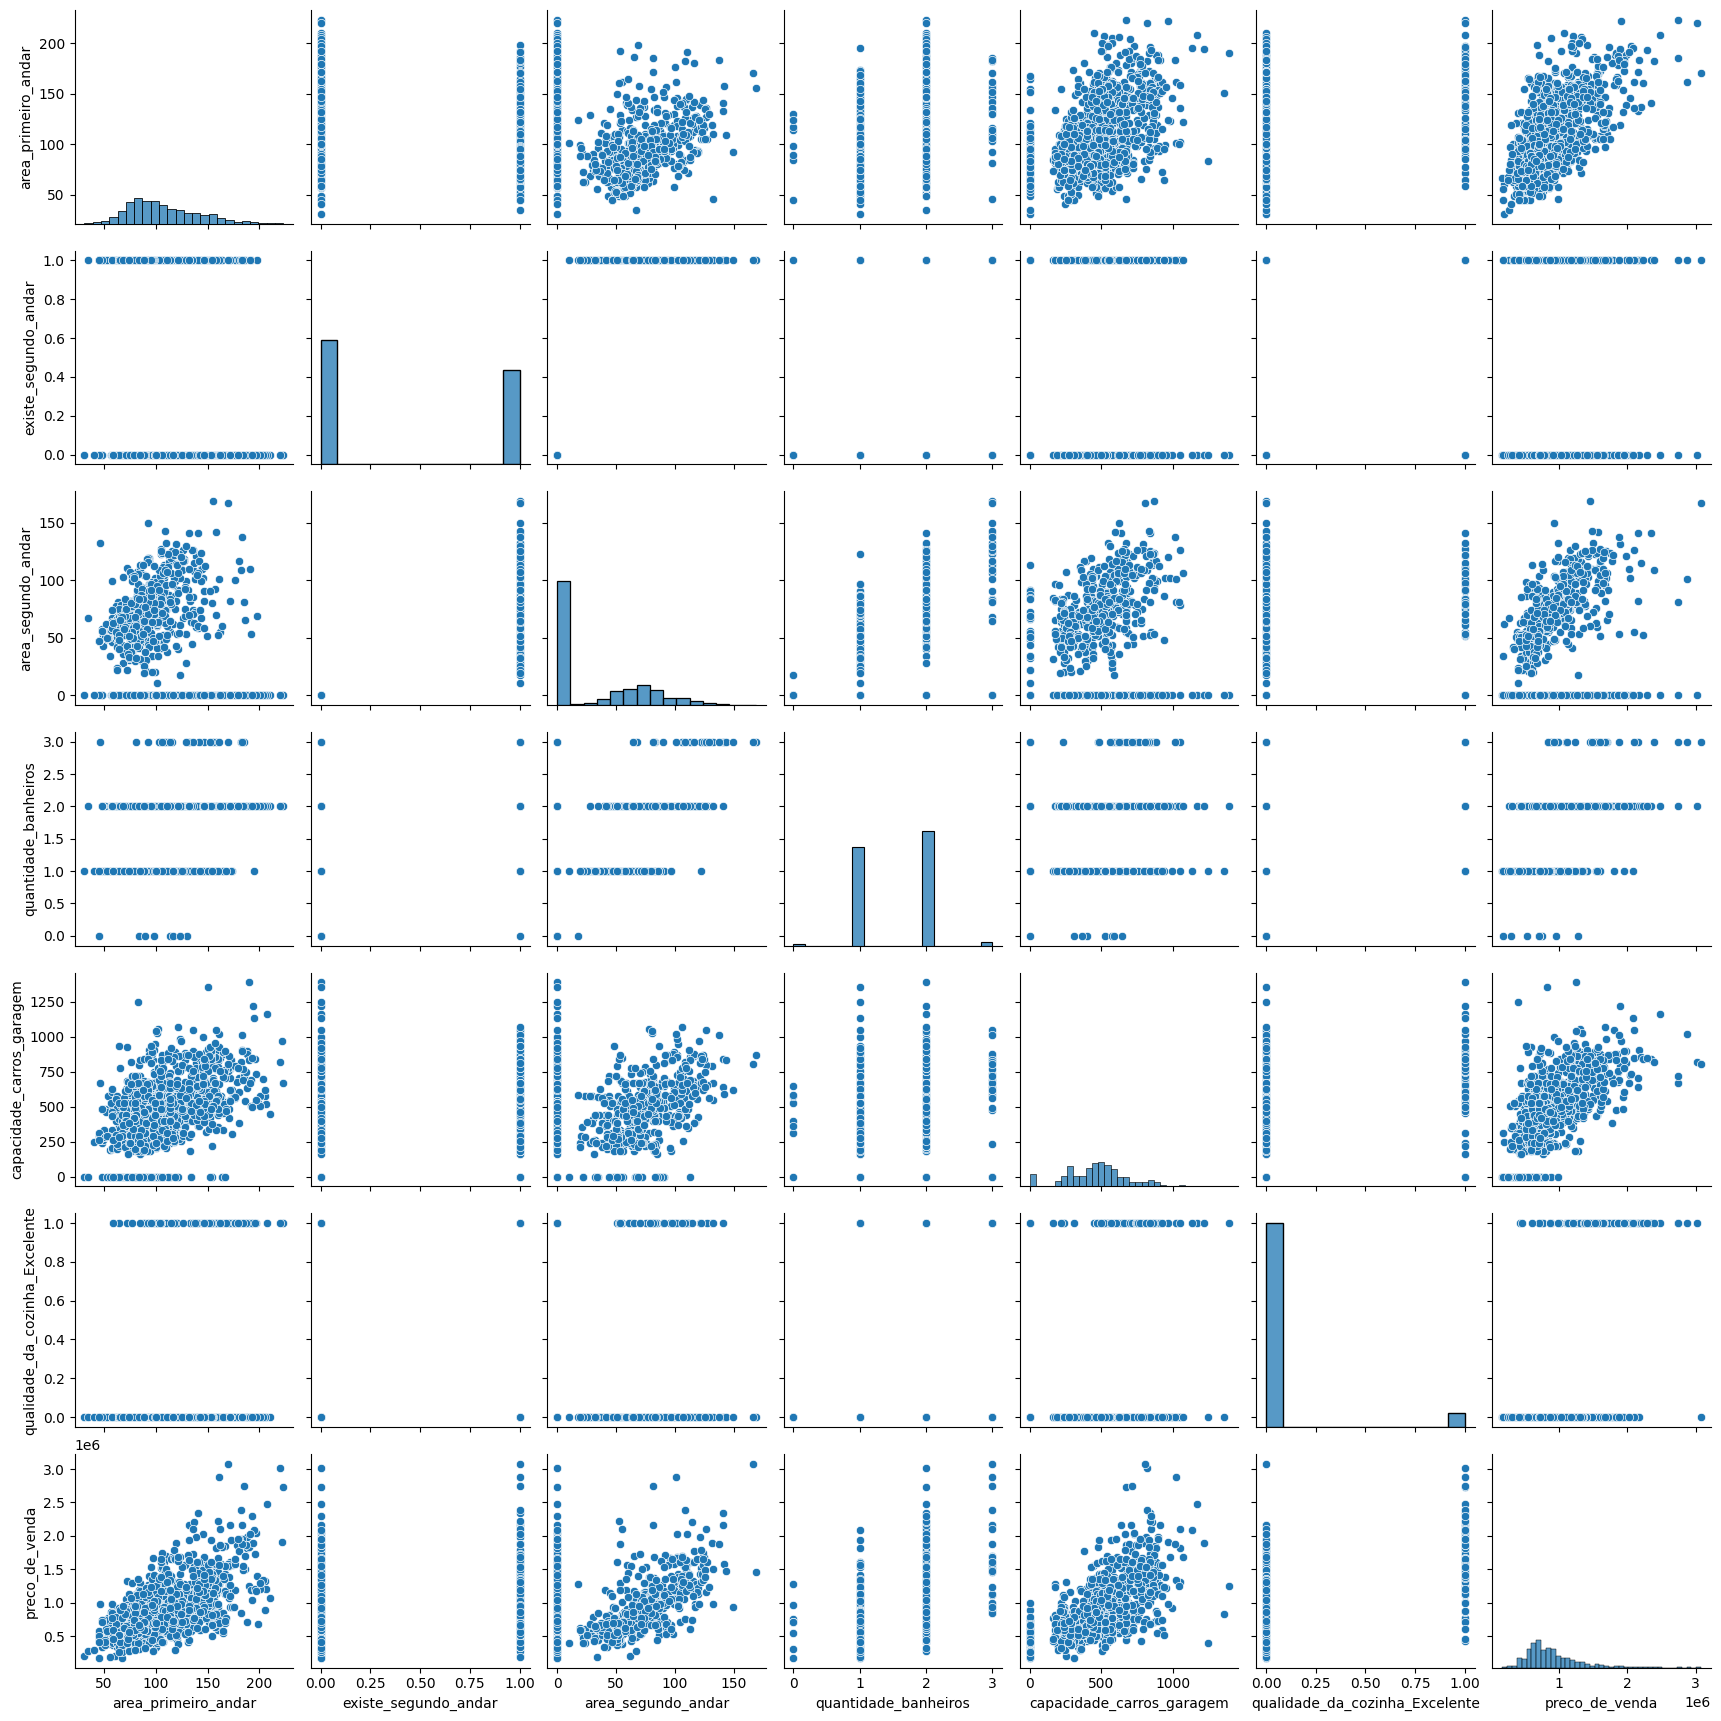

In [20]:
sns.pairplot(dados)

In [21]:
dados.columns

Index(['area_primeiro_andar', 'existe_segundo_andar', 'area_segundo_andar',
       'quantidade_banheiros', 'capacidade_carros_garagem',
       'qualidade_da_cozinha_Excelente', 'preco_de_venda'],
      dtype='object')

In [22]:
#olharaénas para y _vars = preco_de_venda

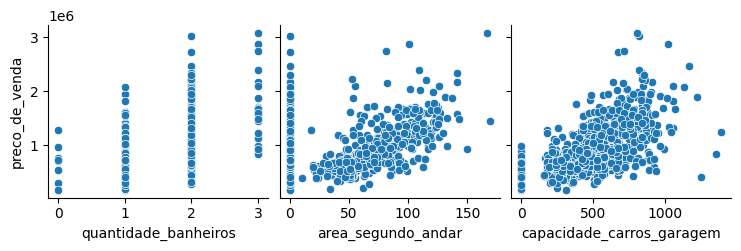

In [24]:
sns.pairplot(dados, y_vars = 'preco_de_venda', x_vars = ['quantidade_banheiros', 'area_segundo_andar', 'capacidade_carros_garagem'])

In [ ]:
#isso foi pra ver quais var podem ajudar a explicar o preco de venda da casa

In [30]:
import statsmodels.api as sm

In [28]:
#add uma constante pra estimar o intercepto
X_train = sm.add_constant(X_train)
X_train.head() #add const 1

,const,area_primeiro_andar,existe_segundo_andar,area_segundo_andar,quantidade_banheiros,capacidade_carros_garagem,qualidade_da_cozinha_Excelente
1303,1.0,65.7732,0,0.0000,1,0,0
326,1.0,55.3684,1,55.3684,1,189,0
386,1.0,74.6916,1,107.4853,2,560,0
615,1.0,103.6764,0,0.0000,1,440,0
236,1.0,94.2006,1,67.8170,2,457,0


Por que usamos o sm.add_constant?No statsmodels, a regressão linear não inclui o intercepto ($\beta_0$) por padrão. Se você não usar esse comando, você está forçando o seu modelo a passar obrigatoriamente pela origem $(0,0)$.1. A Lógica MatemáticaSem a constante, sua previsão de preço de imóvel seria:$$y = \beta_1x_1 + \beta_2x_2 + \dots + \beta_nx_n$$O erro: Se todas as características ($x$) forem 0, o preço ($y$) será obrigatoriamente 0.Com o add_constant, a equação ganha o coeficiente linear:$$y = \beta_0(1) + \beta_1x_1 + \beta_2x_2 + \dots + \beta_nx_n$$2. O que isso significa na prática?O $\beta_0$ (o valor da coluna const) representa o valor base do imóvel.O conceito: Imagine que é o valor do terreno puro, antes de considerar a área construída ou o número de banheiros.A vantagem: Dá liberdade ao modelo para descobrir qual é o "ponto de partida" do preço, tornando as previsões muito mais realistas



In [31]:
X_train.head()

,const,area_primeiro_andar,existe_segundo_andar,area_segundo_andar,quantidade_banheiros,capacidade_carros_garagem,qualidade_da_cozinha_Excelente
1303,1.0,65.7732,0,0.0000,1,0,0
326,1.0,55.3684,1,55.3684,1,189,0
386,1.0,74.6916,1,107.4853,2,560,0
615,1.0,103.6764,0,0.0000,1,440,0
236,1.0,94.2006,1,67.8170,2,457,0


In [32]:
modelo_1 = sm.OLS(y_train,
                  X_train[['const', 'area_primeiro_andar', 'existe_segundo_andar',
                           'area_segundo_andar', 'quantidade_banheiros', 'capacidade_carros_garagem',
                           'qualidade_da_cozinha_Excelente']]).fit()

In [33]:
modelo_2 = sm.OLS(y_train,
                  X_train[['const', 'area_primeiro_andar', 'existe_segundo_andar',
                          'quantidade_banheiros', 'capacidade_carros_garagem',
                           'qualidade_da_cozinha_Excelente']]).fit()

In [34]:
modelo_3 = sm.OLS(y_train,
                  X_train[['const', 'area_primeiro_andar', 'existe_segundo_andar',
                          'quantidade_banheiros', 'qualidade_da_cozinha_Excelente']]).fit()

In [35]:
print(modelo_1.summary())

                            OLS Regression Results                            
Dep. Variable:         preco_de_venda   R-squared:                       0.741
Model:                            OLS   Adj. R-squared:                  0.740
Method:                 Least Squares   F-statistic:                     477.4
Date:                Mon, 16 Mar 2026   Prob (F-statistic):          2.79e-289
Time:                        17:42:43   Log-Likelihood:                -13640.
No. Observations:                1006   AIC:                         2.729e+04
Df Residuals:                     999   BIC:                         2.733e+04
Df Model:                           6                                         
Covariance Type:            nonrobust                                         
                                     coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------------------------
const       

## O que significa **"The condition number is large"**?

O **Condition Number (Número de Condição)** mede a **sensibilidade do seu modelo**.

No seu resultado, o valor **3.24e+03 (3.240)** é considerado **alto** e indica um problema de **multicolinearidade**.


## 1. O que é Multicolinearidade?

Isso acontece quando **duas ou mais variáveis explicativas estão fortemente correlacionadas**, ou seja, elas **“contam a mesma história” para o modelo**.

### Exemplo no seu projeto

Você tem as colunas:

- `existe_segundo_andar`
- `area_segundo_andar`

Se:

- `existe_segundo_andar = 0` → `area_segundo_andar` será **obrigatoriamente 0**
- `existe_segundo_andar = 1` → `area_segundo_andar` será **maior que 0**

### O problema

O modelo entra em **confusão matemática**.  
Ele não consegue distinguir **qual das duas variáveis realmente está afetando o preço**, pois elas **andam juntas**.


## 2. Por que isso é ruim?

### Instabilidade
Pequenas mudanças nos dados podem fazer os **coeficientes ($\beta$)** variarem drasticamente, pulando de valores **positivos para negativos** sem lógica aparente.

### Erro de interpretação
O modelo pode dar um **P-value alto** (dizer que a variável não é importante) apenas porque a informação dela já está **“embutida” na outra variável redundante**.


## 3. Como resolver?

### Remover uma das variáveis
Se você já tem **a área do segundo andar**, a coluna **`existe_segundo_andar`** se torna redundante.  
Tente remover **uma delas** e rodar o modelo novamente.

### VIF (Variance Inflation Factor)
É um **teste estatístico** que identifica **quais colunas estão causando a multicolinearidade**.

### Escalonamento (Standardization)
Colocar os dados **na mesma escala** (por exemplo, tudo entre **0 e 1**) ajuda a **diminuir problemas numéricos no cálculo da matriz**.

In [36]:
print(modelo_2.summary())

                            OLS Regression Results                            
Dep. Variable:         preco_de_venda   R-squared:                       0.708
Model:                            OLS   Adj. R-squared:                  0.707
Method:                 Least Squares   F-statistic:                     485.3
Date:                Mon, 16 Mar 2026   Prob (F-statistic):          1.93e-264
Time:                        17:43:03   Log-Likelihood:                -13701.
No. Observations:                1006   AIC:                         2.741e+04
Df Residuals:                    1000   BIC:                         2.744e+04
Df Model:                           5                                         
Covariance Type:            nonrobust                                         
                                     coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------------------------
const       

Tirou a area segundo andar e o modelo ficou menos confuso (deu numero positivo) mas o condition numver ainda eh large

In [37]:
print(modelo_3.summary())

                            OLS Regression Results                            
Dep. Variable:         preco_de_venda   R-squared:                       0.651
Model:                            OLS   Adj. R-squared:                  0.650
Method:                 Least Squares   F-statistic:                     467.1
Date:                Mon, 16 Mar 2026   Prob (F-statistic):          4.15e-227
Time:                        17:43:08   Log-Likelihood:                -13790.
No. Observations:                1006   AIC:                         2.759e+04
Df Residuals:                    1001   BIC:                         2.762e+04
Df Model:                           4                                         
Covariance Type:            nonrobust                                         
                                     coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------------------------
const       

In [39]:
print("R²:")
print("Modelo 0: ", modelo_0.rsquared)
print("Modelo 1: ", modelo_1.rsquared)
print("Modelo 2: ", modelo_2.rsquared)
print("Modelo 3: ", modelo_3.rsquared)

R²:
Modelo 0:  0.37728010994297867
Modelo 1:  0.7414024156090393
Modelo 2:  0.7081440416220739
Modelo 3:  0.6511289354898803


In [44]:
modelo_0.params
#modelo_0 = ols('preco_de_venda ~ area_primeiro_andar', data = df_train).fit()


,0
Intercept,152909.288334
area_primeiro_andar,6793.641641


In [48]:
 modelo_3.params
#                   modelo_3 = sm.OLS(y_train,
#                   X_train[['const', 'area_primeiro_andar', 'existe_segundo_andar',
#                           'quantidade_banheiros', 'qualidade_da_cozinha_Excelente']]).fit()

,0
const,-129979.678094
area_primeiro_andar,6119.653184
existe_segundo_andar,221306.959705
quantidade_banheiros,149036.289458
qualidade_da_cozinha_Excelente,444391.228573


In [50]:
#Qtos parametros em cada model
print(len(modelo_0.params))
print(len(modelo_1.params))
print(len(modelo_2.params))
print(len(modelo_3.params))


2
7
6
5


Pra escolher o melhor modelo analisaremos o resumo de tds os modelos q ajustamos ate agr

Além da seleção manual que discutimos, existem métodos automáticos de seleção de variáveis que podem ser extremamente úteis em situações onde o número de variáveis explicativas é grande. Esses métodos, como stepwise, backward e forward selection, seguem critérios pré-definidos para adicionar ou remover variáveis do modelo de forma iterativa. Explore a seguir os métodos automáticos de seleção de variáveis, que visam equilibrar a complexidade do modelo e sua capacidade explicativa.

O método forward selection começa com um modelo sem variáveis explicativas e adiciona uma a uma, escolhendo em cada passo a variável que mais melhora o modelo de acordo com um critério estatístico específico, como o menor valor de p-valor ou o maior aumento no R² ajustado.

O backward selection inicia com todas as variáveis possíveis no modelo e, iterativamente, remove a variável que menos contribui para o modelo, novamente baseando-se em critérios como o p-valor ou o impacto no R² ajustado.

O stepwise selection é uma combinação dos dois métodos anteriores, onde as variáveis podem ser adicionadas ou removidas em cada passo, dependendo de sua contribuição para o melhoramento do modelo.

In [51]:
modelo_3.params

,0
const,-129979.678094
area_primeiro_andar,6119.653184
existe_segundo_andar,221306.959705
quantidade_banheiros,149036.289458
qualidade_da_cozinha_Excelente,444391.228573
